# **Phân Cụm Khách Hàng với KMeans và RFM Analysis**
- Sử dụng dữ liệu RFM để phân cụm khách hàng.
- Áp dụng thuật toán **KMeans Clustering** sau khi chuẩn hóa dữ liệu.
- Đánh giá kết quả phân cụm qua **Silhouette Score** và **Elbow Method**.
- Trực quan hóa phân cụm bằng **PCA (Principal Component Analysis)**.

In [53]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, TimestampType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
spark = SparkSession.builder \
    .appName("CustomerSegmentation") \
    .config("spark.sql.iceberg.vectorization.enabled", "false") \
    .getOrCreate()

## **Chuẩn bị dữ liệu**

In [35]:
df = spark.sql("""
        SELECT customer_sk, recency, frequency, monetary 
        FROM lakehouse.gold.customer_rfm;
    """)
df.show(10)

+-----------+-------+---------+--------+
|customer_sk|recency|frequency|monetary|
+-----------+-------+---------+--------+
|          1|    792|        1|  499.95|
|          2|    136|        4|  899.88|
|          3|    229|        5|  827.94|
|          4|    380|        4|  444.92|
|          5|    457|        3|  499.94|
|          6|    646|        4|  609.96|
|          7|    220|        7| 1119.84|
|          8|    126|        8| 1703.89|
|          9|    140|        5| 1224.93|
|         10|    307|        2|  274.95|
+-----------+-------+---------+--------+
only showing top 10 rows



## **Vector hóa & Chuẩn hóa dữ liệu**
- Sử dụng **VectorAssembler** để kết hợp `recency`, `frequency`, `monetary` vào một vector.

In [36]:
assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="rfm_features"
)
assembled_df = assembler.transform(df)
assembled_df.show(5)

+-----------+-------+---------+--------+------------------+
|customer_sk|recency|frequency|monetary|      rfm_features|
+-----------+-------+---------+--------+------------------+
|          1|    792|        1|  499.95|[792.0,1.0,499.95]|
|          2|    136|        4|  899.88|[136.0,4.0,899.88]|
|          3|    229|        5|  827.94|[229.0,5.0,827.94]|
|          4|    380|        4|  444.92|[380.0,4.0,444.92]|
|          5|    457|        3|  499.94|[457.0,3.0,499.94]|
+-----------+-------+---------+--------+------------------+
only showing top 5 rows



- Áp dụng **StandardScaler** để chuẩn hóa giá trị (tránh bias do khác thang đo).

In [37]:
scaler = StandardScaler(
    inputCol="rfm_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)
scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)
scaled_df.show(5)

+-----------+-------+---------+--------+------------------+--------------------+
|customer_sk|recency|frequency|monetary|      rfm_features|     scaled_features|
+-----------+-------+---------+--------+------------------+--------------------+
|          1|    792|        1|  499.95|[792.0,1.0,499.95]|[2.86814013482824...|
|          2|    136|        4|  899.88|[136.0,4.0,899.88]|[-0.4217911206868...|
|          3|    229|        5|  827.94|[229.0,5.0,827.94]|[0.04461681645170...|
|          4|    380|        4|  444.92|[380.0,4.0,444.92]|[0.80190282191326...|
|          5|    457|        3|  499.94|[457.0,3.0,499.94]|[1.18806853330757...|
+-----------+-------+---------+--------+------------------+--------------------+
only showing top 5 rows



## **1. K-MEANS**

### **1.1. Phân tích Elbow Method**
- Chạy **KMeans** với các giá trị **k** từ `2` đến `14`.
- Ghi nhận **WSSSE (Within Set Sum of Squared Errors)** cho từng **k**.

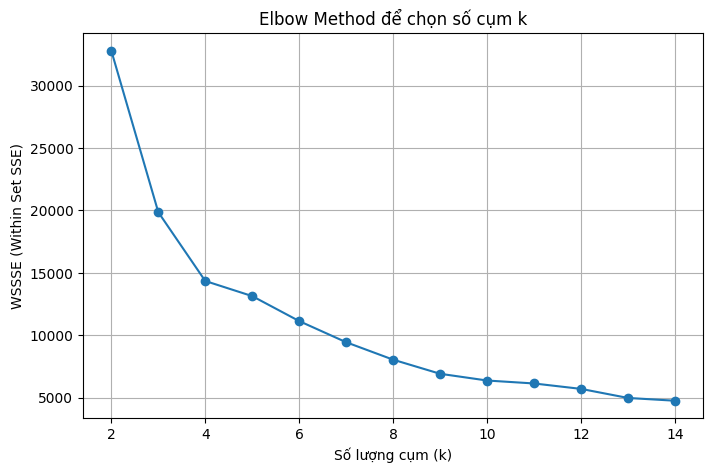

In [38]:
cost = []
K = list(range(2, 15))  # Thử các giá trị k từ 2 đến 5

for k in K:
    kmeans = KMeans(k=k, seed=42, featuresCol="scaled_features")
    model = kmeans.fit(scaled_df)
    wssse = model.summary.trainingCost
    cost.append(wssse)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(K, cost, marker='o')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WSSSE (Within Set SSE)')
plt.title('Elbow Method để chọn số cụm k')
plt.grid(True)
plt.show()


**Nhận xét**
> - Từ `k=2` đến `k=4`: **WSSSE** giảm mạnh → việc tăng số cụm giúp giảm sai số rõ rệt.
> - Từ `k=4` đến `k=6`: **WSSSE** vẫn giảm nhưng chậm lại → hiệu quả tăng cụm bắt đầu giảm.
> - Sau `k=6`: Đường cong bắt đầu phẳng hơn, tức là thêm cụm nữa không giúp giảm sai số nhiều.

**Kết luận**
> - Điểm *“khuỷu tay”* rõ nhất nằm ở `k=3`, `k=4` hoặc `k=5`.
> - Tuy `k=6` cũng còn ổn, nhưng từ `k=7` trở đi gần như hiệu quả giảm **WSSSE** không đáng kể.

### **1.2. Phân tích Silhouette Score và trực quan hóa**

In [43]:
def run_kmeans_for_multiple_k(k_values, scaled_df):
    results = {}
    clustered_dfs = {}

    # Bước 1: Huấn luyện mô hình KMeans cho từng k
    for k in k_values:
        clustered_dfs[k] = _train_kmeans_model(k, scaled_df)
        results[k] = _calculate_silhouette_score(clustered_dfs[k])

    # Bước 2: Áp dụng PCA một lần để trực quan hóa
    pca_data = _prepare_visualization_data(clustered_dfs)

    # Bước 3: Trực quan hóa cụm trong lưới ngang
    _visualize_clusters_grid(pca_data, k_values)

    return results, pca_data


def _train_kmeans_model(k, scaled_df):
    """Huấn luyện mô hình KMeans và trả về DataFrame với nhãn cụm."""
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="scaled_features",
        predictionCol="cluster"
    )
    model = kmeans.fit(scaled_df)
    return model.transform(scaled_df)


def _calculate_silhouette_score(clustered_df):
    """Tính và in silhouette score cho phân cụm."""
    evaluator = ClusteringEvaluator(
        featuresCol="scaled_features",
        predictionCol="cluster",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )
    silhouette = evaluator.evaluate(clustered_df)
    k_value = len(set(row.cluster for row in clustered_df.select("cluster").collect()))
    print(f"k={k_value}: Silhouette Score = {silhouette:.4f}")
    return silhouette


def _prepare_visualization_data(clustered_dfs):
    """
    Áp dụng PCA một lần và chuẩn bị dữ liệu trực quan hóa cho tất cả giá trị k.

    Returns:
    --------
    result : dict
        Từ điển chứa dữ liệu PCA dạng pandas DataFrame cho từng k.
    """
    # Kết hợp tất cả DataFrame
    combined_df = None
    for k, df in clustered_dfs.items():
        df_with_k = df.withColumn("k_value", F.lit(k))
        combined_df = df_with_k if combined_df is None else combined_df.union(df_with_k)

    # Áp dụng PCA để giảm chiều về 2
    pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
    pca_model = pca.fit(combined_df)
    pca_df = pca_model.transform(combined_df)

    # Chuyển sang pandas và tách theo k
    pandas_df = pca_df.select("pca_features", "cluster", "k_value").rdd.map(
        lambda row: (float(row.pca_features[0]), float(row.pca_features[1]), row.cluster, row.k_value)
    ).toDF(["x", "y", "cluster", "k_value"]).toPandas()

    return {k: pandas_df[pandas_df["k_value"] == k][["x", "y", "cluster"]] for k in clustered_dfs}


def _visualize_clusters_grid(pca_data, k_values):
    """Tạo lưới ngang các biểu đồ cụm để so sánh dễ dàng."""
    n_plots = len(k_values)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5), constrained_layout=True)
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan', 'magenta']

    # Tìm min/max chung để đồng bộ tỷ lệ
    x_min = min(pca_data[k]["x"].min() for k in k_values)
    x_max = max(pca_data[k]["x"].max() for k in k_values)
    y_min = min(pca_data[k]["y"].min() for k in k_values)
    y_max = max(pca_data[k]["y"].max() for k in k_values)
    x_pad, y_pad = (x_max - x_min) * 0.1, (y_max - y_min) * 0.1

    # Vẽ từng biểu đồ
    for i, k in enumerate(k_values):
        ax = axes[i] if n_plots > 1 else axes
        plot_data = pca_data[k]

        for cluster_id in sorted(plot_data["cluster"].unique()):
            cluster_data = plot_data[plot_data["cluster"] == cluster_id]
            ax.scatter(
                cluster_data["x"],
                cluster_data["y"],
                label=f"Cụm {cluster_id}",
                alpha=0.7,
                s=50,
                color=colors[cluster_id % len(colors)]
            )

        ax.set_xlim([x_min - x_pad, x_max + x_pad])
        ax.set_ylim([y_min - y_pad, y_max + y_pad])
        ax.set_title(f"Cụm với k = {k}")
        ax.set_xlabel("PCA1")
        ax.set_ylabel("PCA2")
        ax.grid(True)

        if i == 0:
            ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=min(k, 4))

    plt.suptitle("So sánh kết quả phân cụm với các giá trị k", fontsize=16)
    plt.show()



k=3: Silhouette Score = 0.6717
k=4: Silhouette Score = 0.6482
k=5: Silhouette Score = 0.5205


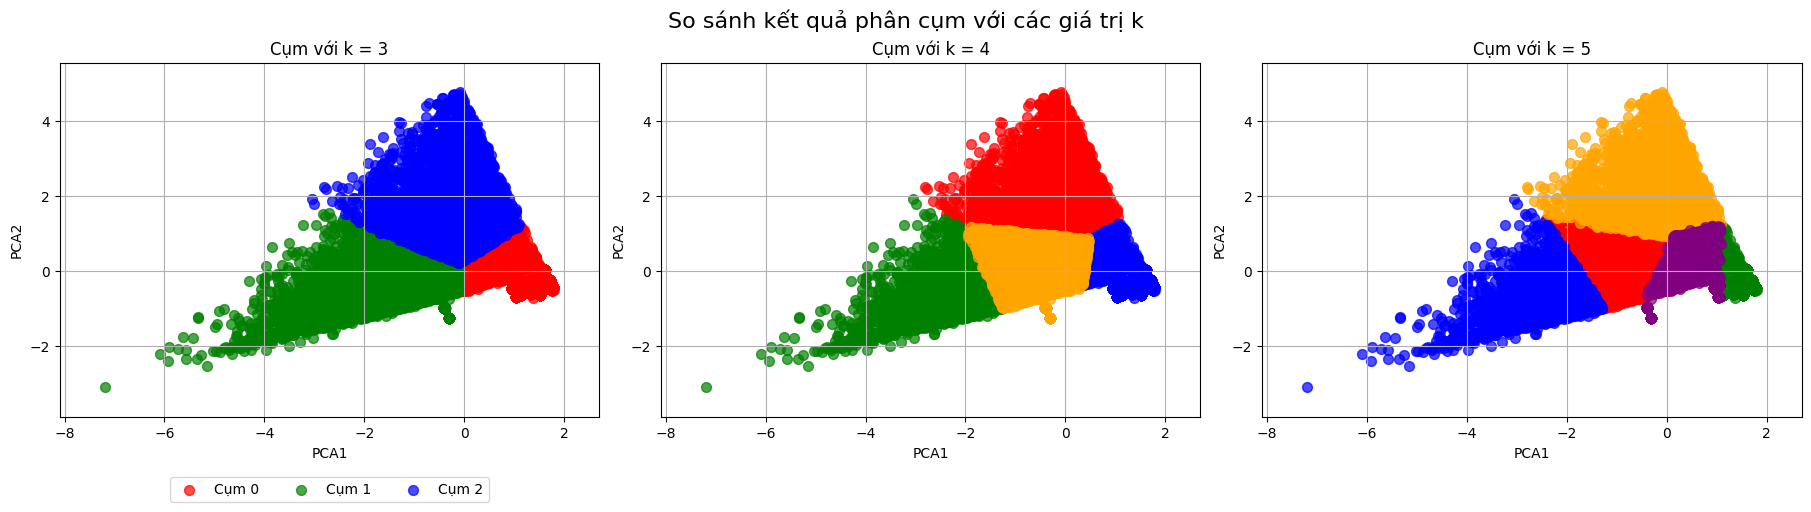

In [44]:
k_values_to_test = [3, 4, 5]
results, pca_data = run_kmeans_for_multiple_k(k_values_to_test, scaled_df)

### **1.3 Nhận xét** 

**Silhouette Score**
- `k = 3` có **Silhouette Score** cao nhất, tức là cụm có sự phân biệt tốt nhất.

**Quan sát trực quan qua PCA.**
- `k = 3`: Các cụm khá rõ ràng, ít chồng lấn.
- `k = 4`: Nhóm thêm màu cam, nhưng bắt đầu thấy hiện tượng cụm bị chia nhỏ một cách “gượng ép”.
- `k = 5`: Một số cụm bắt đầu gối lên nhau nhiều, đặc biệt là cụm tím và xanh lá → làm giảm chất lượng phân cụm.

**Kết luận**    
> *Như vậy, chọn số cụm tối ưu là `k = 3` cho mô hình KMeans hiện tại.*

## **2. Gaussian Mixture Model (GMM)**

### **2.1. Phân tích Elbow Method**
- Chạy **GMM** với các giá trị **k** từ `2` đến `14`.
- Ghi nhận **BIC** cho từng **k**.

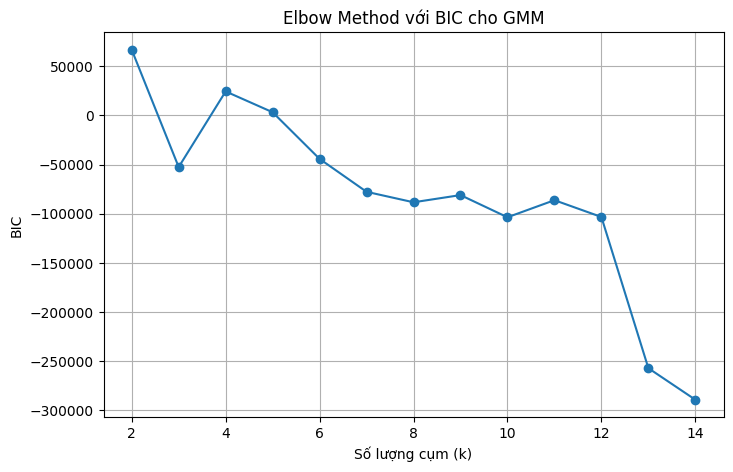

In [54]:
bic_scores = []
K = list(range(2, 15))

num_samples = scaled_df.count()
num_features = scaled_df.select("scaled_features").first()[0].size

for k in K:
    gmm = GaussianMixture(k=k, seed=42, featuresCol="scaled_features")
    model = gmm.fit(scaled_df)
    log_likelihood = model.summary.logLikelihood
    num_params = (k - 1) + k * num_features + k * (num_features * (num_features + 1)) / 2
    bic = -2 * log_likelihood + num_params * np.log(num_samples)
    bic_scores.append(bic)

plt.figure(figsize=(8, 5))
plt.plot(K, bic_scores, marker='o')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('BIC')
plt.title('Elbow Method với BIC cho GMM')
plt.grid(True)
plt.show()

**Nhận xét**
- `k = 3`: **BIC** giảm mạnh từ `k = 2` đến `k = 3`, nhưng sau đó tốc độ giảm chậm lại đáng kể. Cho thấy `k = 3` là một điểm **Elbow* tiềm năng.
- `k = 9` đến `k = 12`: Vùng này **BIC** gần như phẳng, cho thấy việc tăng số cụm từ 9 đến 12 không mang lại cải thiện đáng kể.
- `k = 14`: Mặc dù **BIC** giảm mạnh ở đây, nhưng có thể là dấu hiệu của **overfitting**, vì số cụm lớn thường làm giảm **BIC** nhưng tăng độ phức tạp không cần thiết.

### **2.2. Phân tích Silhouette Score và trực quan hóa**

In [57]:
def run_gmm_for_multiple_k(k_values, scaled_df):
    results = {}
    clustered_dfs = {}

    # Bước 1: Huấn luyện mô hình KMeans cho từng k
    for k in k_values:
        clustered_dfs[k] = _train_gmm_model(k, scaled_df)
        results[k] = _calculate_silhouette_score(clustered_dfs[k])

    # Bước 2: Áp dụng PCA một lần để trực quan hóa
    pca_data = _prepare_visualization_data(clustered_dfs)

    # Bước 3: Trực quan hóa cụm trong lưới ngang
    _visualize_clusters_grid(pca_data, k_values)

    return results, pca_data


def _train_gmm_model(k, scaled_df):
    """Huấn luyện mô hình KMeans và trả về DataFrame với nhãn cụm."""
    gmm = GaussianMixture(
        k=k,
        seed=42,
        featuresCol="scaled_features",
        predictionCol="cluster"
    )
    model = gmm.fit(scaled_df)
    return model.transform(scaled_df)


def _calculate_silhouette_score(clustered_df):
    """Tính và in silhouette score cho phân cụm."""
    evaluator = ClusteringEvaluator(
        featuresCol="scaled_features",
        predictionCol="cluster",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )
    silhouette = evaluator.evaluate(clustered_df)
    k_value = len(set(row.cluster for row in clustered_df.select("cluster").collect()))
    print(f"k={k_value}: Silhouette Score = {silhouette:.4f}")
    return silhouette


def _prepare_visualization_data(clustered_dfs):
    """
    Áp dụng PCA một lần và chuẩn bị dữ liệu trực quan hóa cho tất cả giá trị k.

    Returns:
    --------
    result : dict
        Từ điển chứa dữ liệu PCA dạng pandas DataFrame cho từng k.
    """
    # Kết hợp tất cả DataFrame
    combined_df = None
    for k, df in clustered_dfs.items():
        df_with_k = df.withColumn("k_value", F.lit(k))
        combined_df = df_with_k if combined_df is None else combined_df.union(df_with_k)

    # Áp dụng PCA để giảm chiều về 2
    pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
    pca_model = pca.fit(combined_df)
    pca_df = pca_model.transform(combined_df)

    # Chuyển sang pandas và tách theo k
    pandas_df = pca_df.select("pca_features", "cluster", "k_value").rdd.map(
        lambda row: (float(row.pca_features[0]), float(row.pca_features[1]), row.cluster, row.k_value)
    ).toDF(["x", "y", "cluster", "k_value"]).toPandas()

    return {k: pandas_df[pandas_df["k_value"] == k][["x", "y", "cluster"]] for k in clustered_dfs}


def _visualize_clusters_grid(pca_data, k_values):
    """Tạo lưới ngang các biểu đồ cụm để so sánh dễ dàng."""
    n_plots = len(k_values)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5), constrained_layout=True)
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan', 'magenta']

    # Tìm min/max chung để đồng bộ tỷ lệ
    x_min = min(pca_data[k]["x"].min() for k in k_values)
    x_max = max(pca_data[k]["x"].max() for k in k_values)
    y_min = min(pca_data[k]["y"].min() for k in k_values)
    y_max = max(pca_data[k]["y"].max() for k in k_values)
    x_pad, y_pad = (x_max - x_min) * 0.1, (y_max - y_min) * 0.1

    # Vẽ từng biểu đồ
    for i, k in enumerate(k_values):
        ax = axes[i] if n_plots > 1 else axes
        plot_data = pca_data[k]

        for cluster_id in sorted(plot_data["cluster"].unique()):
            cluster_data = plot_data[plot_data["cluster"] == cluster_id]
            ax.scatter(
                cluster_data["x"],
                cluster_data["y"],
                label=f"Cụm {cluster_id}",
                alpha=0.7,
                s=50,
                color=colors[cluster_id % len(colors)]
            )

        ax.set_xlim([x_min - x_pad, x_max + x_pad])
        ax.set_ylim([y_min - y_pad, y_max + y_pad])
        ax.set_title(f"Cụm với k = {k}")
        ax.set_xlabel("PCA1")
        ax.set_ylabel("PCA2")
        ax.grid(True)

        if i == 0:
            ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=min(k, 4))

    plt.suptitle("So sánh kết quả phân cụm với các giá trị k", fontsize=16)
    plt.show()



k=3: Silhouette Score = 0.4583


k=8: Silhouette Score = 0.4200


k=10: Silhouette Score = 0.3998


k=12: Silhouette Score = 0.3515


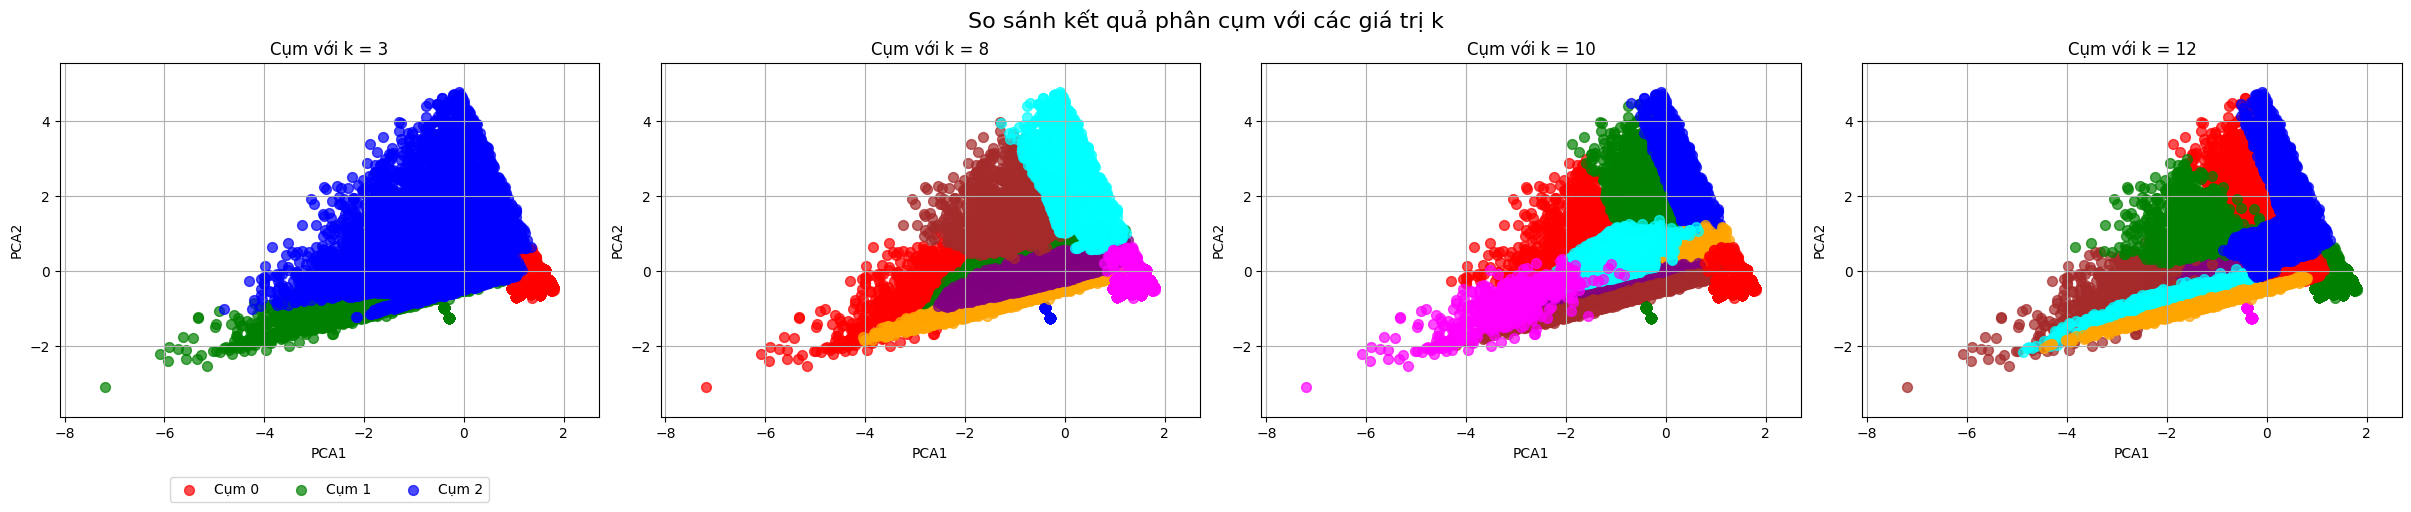

In [60]:
k_values = [3, 8, 10, 12]
results, pca_data = run_gmm_for_multiple_k(k_values, scaled_df)

### **2.3 Nhận xét** 

**Silhouette Score**
- `k = 3` có **Silhouette Score** cao nhất, tức là cụm có sự phân biệt tốt nhất.

**Quan sát trực quan qua PCA.**
- `k = 3`: Các cụm khá rõ ràng, ít chồng lấn hơn những trườn hợp khách.
- `k = 8, 10, 12`:Càng nhiều cụm, càng có dấu hiệu overfitting, một số cụm chồng chéo hoặc quá nhỏ. Dễ xảy ra hiện tượng phân cụm "mảnh vụn", làm giảm ý nghĩa phân tích.

**Kết luận**    
> *Như vậy, chọn số cụm tối ưu là `k = 3` cho mô hình GMM hiện tại.*

## **Phân tích đặc điểm các cụm**
Mô hình Kmeans với `k=3` cho kết quả phân cụm tốt nhất với Silhouette Score = 0.6717 và hình ảnh kết quả phân cụm ít bị chồng lấn nhất.

In [65]:
kmeans = KMeans(k=3, seed=42, featuresCol="scaled_features")
model = kmeans.fit(scaled_df)
predictions = model.transform(scaled_df)
predictions.select("customer_sk", "recency", "frequency", "monetary", "prediction").show(10)

+-----------+-------+---------+--------+----------+
|customer_sk|recency|frequency|monetary|prediction|
+-----------+-------+---------+--------+----------+
|          1|    792|        1|  499.95|         2|
|          2|    136|        4|  899.88|         1|
|          3|    229|        5|  827.94|         1|
|          4|    380|        4|  444.92|         2|
|          5|    457|        3|  499.94|         2|
|          6|    646|        4|  609.96|         2|
|          7|    220|        7| 1119.84|         1|
|          8|    126|        8| 1703.89|         1|
|          9|    140|        5| 1224.93|         1|
|         10|    307|        2|  274.95|         0|
+-----------+-------+---------+--------+----------+
only showing top 10 rows



In [68]:
# Nhóm theo cụm và tính trung bình các đặc trưng
cluster_summary = predictions.groupBy("prediction").agg(
    F.avg("recency").alias("avg_recency"),
    F.avg("frequency").alias("avg_frequency"),
    F.avg("monetary").alias("avg_monetary"),
    F.count("customer_sk").alias("customer_count")
)

cluster_summary.show()

+----------+-----------------+------------------+------------+--------------+
|prediction|      avg_recency|     avg_frequency|avg_monetary|customer_count|
+----------+-----------------+------------------+------------+--------------+
|         2| 546.386992743886|2.9927438860521365|  503.319186|          3721|
|         1|  231.02344790834| 5.678390620836664| 1125.735915|          7506|
|         0|82.59002652519894|1.2725729442970821|  259.739913|          9425|
+----------+-----------------+------------------+------------+--------------+



**Bảng thống kê các cụm khách hàng theo RFM**

| Cụm | Số khách hàng | Recency trung bình | Frequency trung bình | Monetary trung bình |
|------|----------------|----------------------|------------------------|------------------------|
| 0    | 9,425          | 82.59 *(thấp)*       | 1.27 *(thấp)*          | 259.74 *(thấp)*        |
| 1    | 7,506          | 231.02 *(trung bình)*| 5.68 *(cao)*           | 1,125.74 *(cao)*       |
| 2    | 3,721          | 546.39 *(cao)*       | 2.99 *(trung bình)*    | 503.32 *(trung bình)*

**Cụm 0 – Khách hàng không hoạt động gần đây, giá trị thấp**
> - Recency thấp: Vừa mua sắm gần đây.
> - Frequency thấp: Tần suất mua sắm thấp.
> - Monetary thấp: Chi tiêu thấp.
> - **Ý nghĩa**: Nhóm khách hàng mới hoặc khách không trung thành. Họ mua lẻ tẻ với giá trị nhỏ.
> - **Chiến lược**: Gửi ưu đãi cho lần mua tiếp theo. Tạo động lực để tăng tần suất mua hàng.

**Cụm 1 – Khách hàng VIP**
> - Recency trung bình: Không quá gần đây, nhưng vẫn còn hoạt động.
> - Frequency cao: Mua sắm thường xuyên.
> - Monetary cao: Chi tiêu lớn.
> - **Ý nghĩa**: Nhóm khách hàng trung thành và có giá trị cao nhất.
> - **Chiến lược**: Giữ chân bằng chương trình khách hàng thân thiết. Ưu đãi độc quyền hoặc sản phẩm cao cấp.

**Cụm 2 – Khách hàng không hoạt động, giá trị trung bình**
> - Recency cao: Đã lâu không quay lại mua hàng.
> - Frequency trung bình: Có lịch sử mua vừa phải.
> - Monetary trung bình: Giá trị chi tiêu trung bình.
> - Ý nghĩa: Đây là nhóm có nguy cơ rời bỏ (churn) cao.
> - Chiến lược: Gửi email cá nhân hóa. Chiến dịch khuyến mãi để kéo khách quay lại.



## dsds

In [70]:
customer_df = spark.sql("""
        SELECT *
        FROM lakehouse.gold.dim_customer;
    """)
customer_df.show(10)

+-----------+-----------+--------------+--------------+--------------------+------------------+-------------------+---------------+----------+
|customer_sk|customer_id|customer_fname|customer_lname|      customer_email|sales_per_customer|     effective_date|expiration_date|is_current|
+-----------+-----------+--------------+--------------+--------------------+------------------+-------------------+---------------+----------+
|          1|          1|       Richard|     Hernandez|richard.hernandez...|            499.95|2015-01-01 00:00:00|           NULL|         1|
|          2|          2|          Mary|       Barrett|mary.barrett329@y...|            899.88|2015-01-01 00:00:00|           NULL|         1|
|          3|          3|           Ann|         Smith|ann.smith313@gmai...|            827.94|2015-01-01 00:00:00|           NULL|         1|
|          4|          4|          Mary|         Jones|mary.jones139@gma...|            444.92|2015-01-01 00:00:00|           NULL|         1|